<a href="https://colab.research.google.com/github/Harnzt/Analisis-dan-Visualisasi-Data/blob/main/HR_Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Analisis Employee Attrition IBM HR Analytics



In [17]:

# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Load dataset
df = pd.read_csv('HR-Employee-Attrition.csv')

# Tampilkan data awal
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1. Exploratory Data Analysis (EDA)

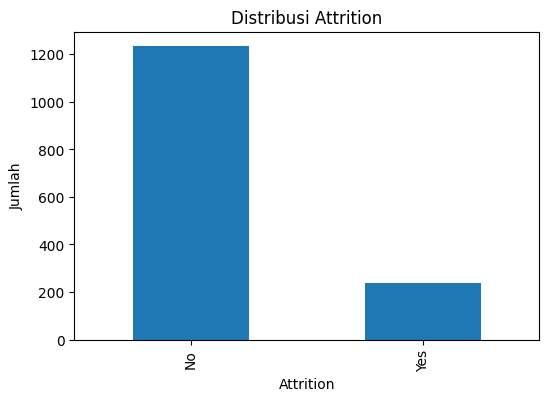

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [3]:

# Distribusi Attrition
attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(6,4))
attrition_counts.plot(kind='bar')
plt.title('Distribusi Attrition')
plt.xlabel('Attrition')
plt.ylabel('Jumlah')
plt.show()

print(attrition_counts)


grafik Distribusi Attrition menunjukkan adanya ketidakseimbangan data (imbalanced data) yang signifikan antara karyawan yang bertahan dan yang keluar. Mayoritas karyawan (sekitar 1.233 orang) memilih untuk tidak keluar (No), sementara hanya sebagian kecil (sekitar 237 orang) yang tercatat keluar (Yes). Kondisi ini penting untuk diperhatikan karena akan memengaruhi cara model mesin pembelajaran memprediksi kelas minoritas (karyawan yang keluar).

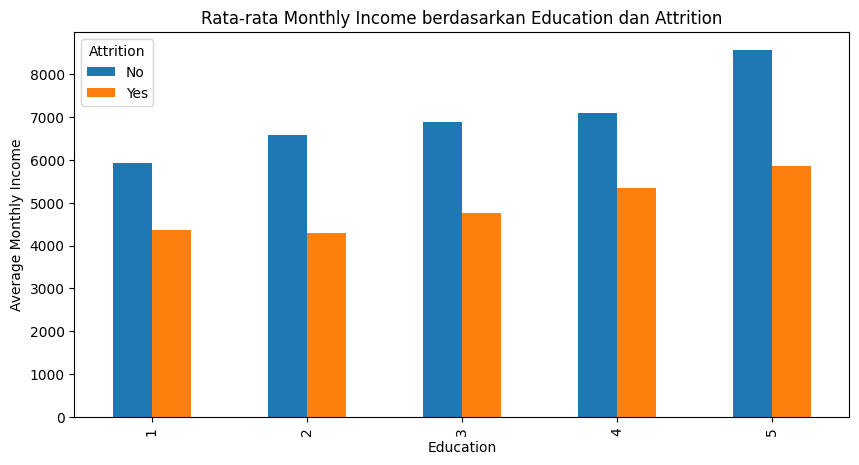

Attrition,No,Yes
Education,,
1,5926.129496,4360.161290
2,6586.058824,4282.545455
3,6882.919662,4770.242424
4,7087.814706,5335.155172
5,8559.906977,5850.200000


In [4]:

# Rata-rata Monthly Income berdasarkan Education dan Attrition
income_edu = df.groupby(['Education', 'Attrition'])['MonthlyIncome'].mean().unstack()

income_edu.plot(kind='bar', figsize=(10,5))
plt.title('Rata-rata Monthly Income berdasarkan Education dan Attrition')
plt.ylabel('Average Monthly Income')
plt.show()

income_edu


rata-rata Monthly Income cenderung meningkat seiring dengan tingginya tingkat pendidikan (level 1 hingga 5). Namun, terlihat pola konsisten di semua tingkat pendidikan bahwa karyawan yang keluar (Attrition: Yes) memiliki rata-rata penghasilan yang jauh lebih rendah dibandingkan mereka yang bertahan (Attrition: No). Hal ini mengindikasikan bahwa kesenjangan kompensasi pada tingkat pendidikan yang sama merupakan salah satu faktor pendorong utama karyawan memutuskan untuk meninggalkan perusahaan.

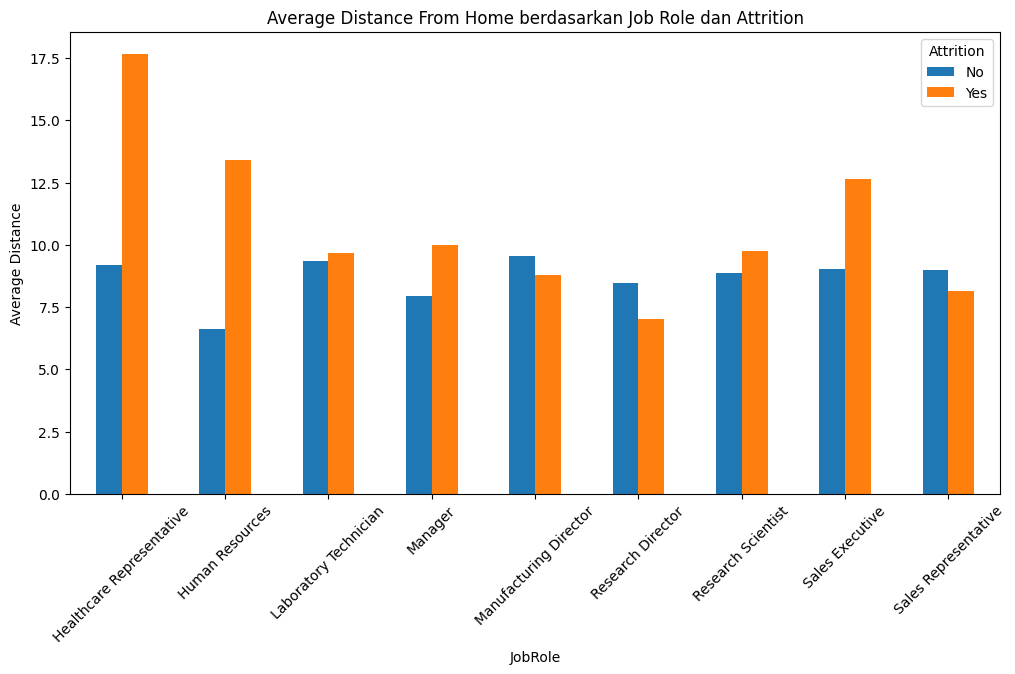

Attrition,No,Yes
JobRole,,
Healthcare Representative,9.204918,17.666667
Human Resources,6.600000,13.416667
Laboratory Technician,9.329949,9.661290
Manager,7.927835,10.000000
Manufacturing Director,9.533333,8.800000
Research Director,8.474359,7.000000
Research Scientist,8.869388,9.765957
Sales Executive,9.026022,12.649123
Sales Representative,9.000000,8.151515


In [5]:

# Distance From Home berdasarkan Job Role dan Attrition
distance_job = df.groupby(['JobRole', 'Attrition'])['DistanceFromHome'].mean().unstack()

distance_job.plot(kind='bar', figsize=(12,6))
plt.title('Average Distance From Home berdasarkan Job Role dan Attrition')
plt.ylabel('Average Distance')
plt.xticks(rotation=45)
plt.show()

distance_job


jarak dari rumah ke kantor memiliki pengaruh yang bervariasi terhadap keputusan karyawan untuk keluar tergantung pada peran pekerjaan mereka. Terlihat jelas pada peran seperti Healthcare Representative dan Human Resources, karyawan yang keluar (Attrition: Yes) memiliki rata-rata jarak tempuh yang jauh lebih tinggi dibandingkan mereka yang bertahan. Hal ini menunjukkan bahwa bagi posisi tertentu, jarak tempuh yang jauh menjadi faktor pendorong signifikan terhadap attrition, sementara pada posisi lain seperti Manufacturing Director, pengaruh jarak cenderung lebih minim.

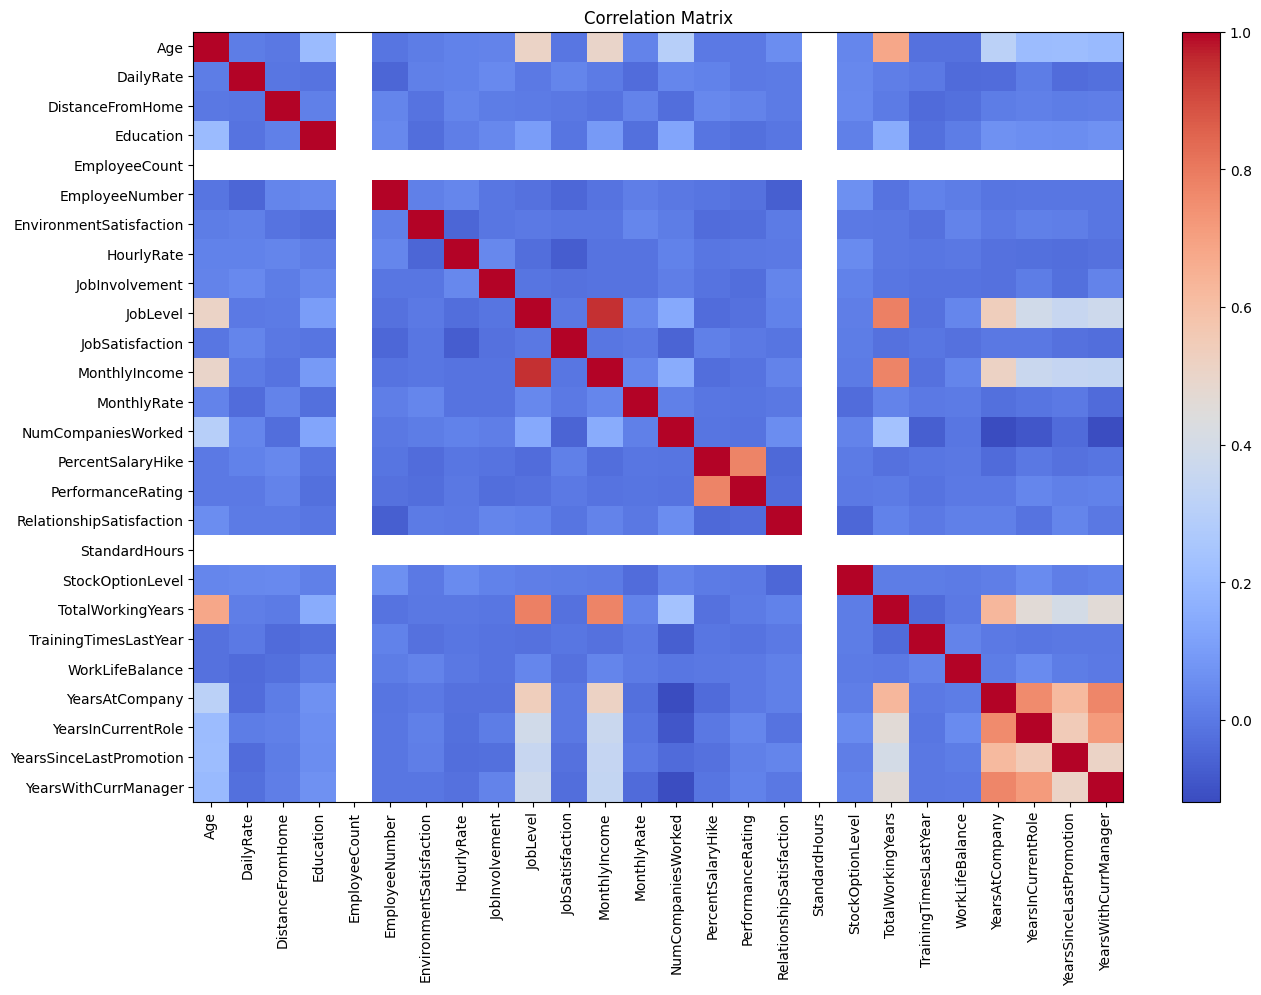

In [6]:

# Korelasi fitur numerik
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(15,10))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title('Correlation Matrix')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()


## 2. Feature Engineering dan Encoding

In [7]:

# Copy dataset
data = df.copy()

# Hapus kolom yang tidak relevan / konstan
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
data.drop(columns=drop_cols, inplace=True)

# Encode target
data['Attrition'] = data['Attrition'].map({'Yes':1, 'No':0})

# Pisahkan fitur kategorikal dan numerik
categorical_cols = data.select_dtypes(include='object').columns.tolist()
numerical_cols = data.select_dtypes(exclude='object').columns.tolist()

numerical_cols.remove('Attrition')

print('Categorical Columns:', categorical_cols)
print('Numerical Columns:', numerical_cols)


Categorical Columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical Columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [8]:

# One Hot Encoding
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print(data_encoded.shape)
data_encoded.head()


(1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


## 3. Machine Learning Model

In [9]:

# Pisahkan fitur dan target
X = data_encoded.drop('Attrition', axis=1)
y = data_encoded['Attrition']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardisasi
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)


(1176, 44) (294, 44)


In [10]:

# Model Logistic Regression
logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train_scaled, y_train)

y_pred_log = logreg.predict(X_test_scaled)

print('Accuracy Logistic Regression:', accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Accuracy Logistic Regression: 0.8605442176870748
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [11]:

# Model Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print('Accuracy Decision Tree:', accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Accuracy Decision Tree: 0.7653061224489796
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       247
           1       0.31      0.38      0.34        47

    accuracy                           0.77       294
   macro avg       0.59      0.61      0.60       294
weighted avg       0.79      0.77      0.77       294



In [12]:

# Model Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('Accuracy Random Forest:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy Random Forest: 0.826530612244898
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       247
           1       0.33      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.59      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



In [13]:
report_log = classification_report(y_test, y_pred_log, output_dict=True)
report_dt = classification_report(y_test, y_pred_dt, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        report_log['accuracy'],
        report_dt['accuracy'],
        report_rf['accuracy']
    ],
    'Precision (Yes)': [
        report_log['1']['precision'],
        report_dt['1']['precision'],
        report_rf['1']['precision']
    ],
    'Recall (Yes)': [
        report_log['1']['recall'],
        report_dt['1']['recall'],
        report_rf['1']['recall']
    ],
    'F1-Score (Yes)': [
        report_log['1']['f1-score'],
        report_dt['1']['f1-score'],
        report_rf['1']['f1-score']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)


                 Model  Accuracy  Precision (Yes)  Recall (Yes)  \
0  Logistic Regression  0.860544         0.615385      0.340426   
1        Decision Tree  0.765306         0.310345      0.382979   
2        Random Forest  0.826531         0.333333      0.085106   

   F1-Score (Yes)  
0        0.438356  
1        0.342857  
2        0.135593  


Berdasarkan hasil perbandingan model, Logistic Regression merupakan model yang paling cocok untuk dataset ini karena memiliki tingkat akurasi tertinggi sebesar 86% dan F1-Score untuk kelas 'Yes' (karyawan yang keluar) yang paling unggul dibandingkan model lainnya. Meskipun Random Forest sering kali dianggap lebih kuat, pada kasus ini model tersebut mengalami kesulitan dalam mendeteksi karyawan yang benar-benar akan keluar, terlihat dari nilai Recall yang sangat rendah (8%). Logistic Regression memberikan keseimbangan yang lebih baik antara presisi dan daya tangkap (recall), sehingga perusahaan dapat mengidentifikasi potensi pengunduran diri dengan tingkat kesalahan prediksi yang lebih minim dibandingkan Decision Tree atau Random Forest.

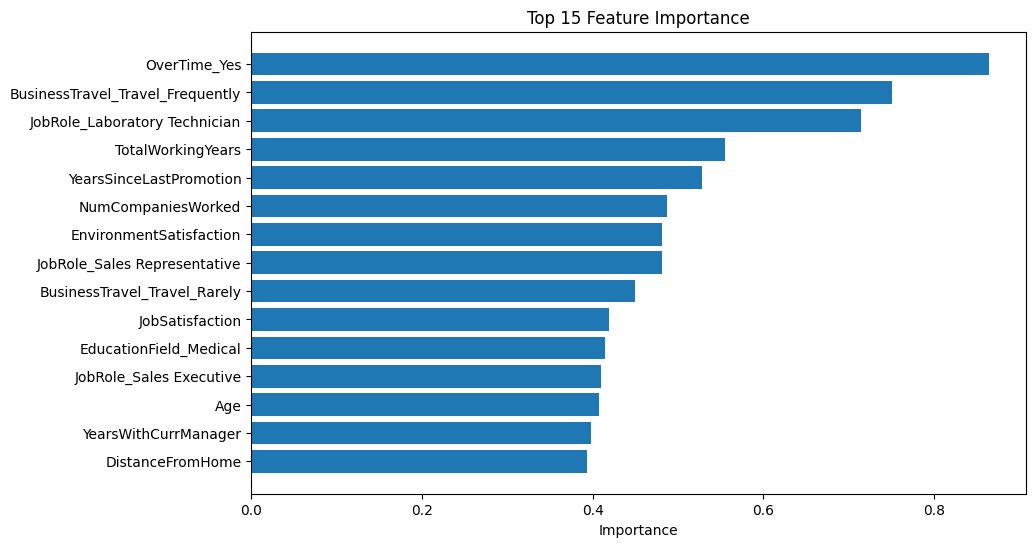

,Feature,Importance
43,OverTime_Yes,0.864567
23,BusinessTravel_Travel_Frequently,0.751247
34,JobRole_Laboratory Technician,0.714756
16,TotalWorkingYears,0.555603
21,YearsSinceLastPromotion,0.528704
11,NumCompaniesWorked,0.487609
4,EnvironmentSatisfaction,0.481659
40,JobRole_Sales Representative,0.481459
24,BusinessTravel_Travel_Rarely,0.450070
8,JobSatisfaction,0.419417


In [16]:

# Feature Importance dari Logistic Regression
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(logreg.coef_[0]) # Using absolute coefficients for Logistic Regression
})

importance = importance.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importance')
plt.xlabel('Importance')
plt.show()

importance


Berdasarkan hasil analisis, model Logistic Regression memberikan gambaran jelas tentang faktor apa saja yang paling mendorong karyawan untuk keluar (attrition). Faktor OverTime (lembur) menjadi prediktor terkuat, diikuti oleh frekuensi perjalanan bisnis (Business Travel) dan peran pekerjaan tertentu seperti Laboratory Technician.
Selain itu, variabel TotalWorkingYears dan YearsSinceLastPromotion juga memiliki tingkat importance yang signifikan, yang menunjukkan bahwa masa kerja dan kejelasan jenjang karier sangat memengaruhi keputusan karyawan. Dengan memahami tingkat kepentingan (importance) dari fitur-fitur ini, perusahaan dapat memprioritaskan kebijakan seperti peninjauan beban kerja lembur atau evaluasi sistem promosi untuk menekan angka turnover.